Stage 1 (Capacity Check): Can the MLP backbone $H_\theta(x,y)$ memorize 128 ground-truth solutions simultaneously using a pure Data Loss?  
Result: The network has the capacity to memorize 1000 samples.

Stage 2 (Zero-Shot PDE Solve): Can the data-pretrained basis functions solve unseen samples via 1-shot linear solve without retraining?  
Stage 3 (Physics Fine-Tuning): Does switching to pure PDE + BC loss (differentiable direct solve) improve or degrade the representation?  

In [ ]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial, tree_map
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
import h5py
from tqdm.auto import tqdm

config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'

In [ ]:
beta = 10.0

DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
scale_factor = 1
NEW_FILE_PATH = DATA_DIR / f"2D_DarcyFlow_beta10.0_Train_Scale{scale_factor}.hdf5"

print(f"Loading pre-processed dataset: {NEW_FILE_PATH.name}")

with h5py.File(NEW_FILE_PATH, 'r') as f:
    fine_x_coords = np.array(f['x-coordinate'][:])
    fine_y_coords = np.array(f['y-coordinate'][:])
    
    all_a_flat = np.array(f['a_flat'][:])
    all_a_x_flat = np.array(f['a_x_flat'][:])
    all_a_y_flat = np.array(f['a_y_flat'][:])
    all_u_flat = np.array(f['u_flat'][:])

N_samples = all_a_flat.shape[0]
fine_nx, fine_ny = len(fine_x_coords), len(fine_y_coords)

x_l, x_u = float(np.min(fine_x_coords)), float(np.max(fine_x_coords)) 
y_l, y_u = float(np.min(fine_y_coords)), float(np.max(fine_y_coords)) 

X, Y = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')
x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_valid = x
y_valid = y
total_valid_points = x_valid.shape[0]

# Generate True Mathematical Boundaries
edge_x = jnp.linspace(0.0, 1.0, fine_nx)
edge_y = jnp.linspace(0.0, 1.0, fine_ny)

bc_bottom = jnp.stack([edge_x, jnp.zeros_like(edge_x)], axis=-1)
bc_top = jnp.stack([edge_x, jnp.ones_like(edge_x)], axis=-1)
bc_left = jnp.stack([jnp.zeros_like(edge_y), edge_y], axis=-1)
bc_right = jnp.stack([jnp.ones_like(edge_y), edge_y], axis=-1)

all_bc_coords = jnp.concatenate([bc_bottom, bc_top, bc_left, bc_right], axis=0)
x_bc = all_bc_coords[:, 0].reshape(-1, 1)
y_bc = all_bc_coords[:, 1].reshape(-1, 1)

bc_val_array = jnp.zeros_like(x_bc)

Loading pre-processed dataset: 2D_DarcyFlow_beta10.0_Train_Scale1.hdf5


E0730 23:47:09.302870  462054 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0730 23:47:09.372849  461937 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [ ]:
class DarcyFlowDataset(Dataset):
    def __init__(self, a_data, a_x_data, a_y_data, u_data):
        self.a = a_data
        self.a_x = a_x_data
        self.a_y = a_y_data
        self.u = u_data

    def __len__(self): return len(self.a)
    def __getitem__(self, idx): return self.a[idx], self.a_x[idx], self.a_y[idx], self.u[idx]

# Locking in 128 samples to test the hypothesis
n_train = 128
n_val = 10
n_test = 10
N_subset = n_train + n_val + n_test

train_dataset = DarcyFlowDataset(
    all_a_flat[:n_train], all_a_x_flat[:n_train], 
    all_a_y_flat[:n_train], all_u_flat[:n_train]
)

val_dataset = DarcyFlowDataset(
    all_a_flat[n_train : n_train + n_val], all_a_x_flat[n_train : n_train + n_val], 
    all_a_y_flat[n_train : n_train + n_val], all_u_flat[n_train : n_train + n_val]
)

test_dataset = DarcyFlowDataset(
    all_a_flat[n_train + n_val : N_subset], all_a_x_flat[n_train + n_val : N_subset], 
    all_a_y_flat[n_train + n_val : N_subset], all_u_flat[n_train + n_val : N_subset]
)

batch_size_samples = 8
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=n_val, shuffle=False)
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=n_test, shuffle=False)

print(f"DataLoaders ready! (Train: {n_train}, Val: {n_val}, Test: {n_test})")

DataLoaders ready! (Train: 1000, Val: 10, Test: 10)


In [ ]:
M = 1024
chunk_size = 256 
hidden_layers = [512,512,512,512] 
total_features = hidden_layers[-1]

sigma = 1
tik_reg_fixed = 1e-6
matrix_bc_weight = 1e2
pde_loss_weight = 1.0
bc_loss_weight = 1e2
data_loss_weight = 0.0

rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.glorot_normal())(h)
            h = nn.tanh(h) 
        return h 
    
model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix=B_matrix)
key = jax.random.PRNGKey(0)
initial_params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

# --- Network Helper Functions ---
def get_f(params, x_val, y_val): return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    return jnp.squeeze(f_x, axis=-1), jnp.squeeze(f_y, axis=-1), jnp.squeeze(f_xx, axis=(-1, -2)), jnp.squeeze(f_yy, axis=(-1, -2))

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_x_chunk = jacfwd(get_f_chunk, argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_y_chunk = jacfwd(get_f_chunk, argnums=2)(params, x_val, y_val, start_idx, end_idx)
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    return jnp.squeeze(f_x_chunk, axis=-1), jnp.squeeze(f_y_chunk, axis=-1), jnp.squeeze(f_xx_chunk, axis=(-1, -2)), jnp.squeeze(f_yy_chunk, axis=(-1, -2))

def get_u_dir(params, x_val, y_val, w_current):
    f_x, f_y, f_xx, f_yy = get_f_dir(params, x_val, y_val)
    return jnp.dot(f_x, w_current), jnp.dot(f_y, w_current), jnp.dot(f_xx, w_current), jnp.dot(f_yy, w_current)

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

# --- Matrix Assembly ---
def multiply_coefficients(f_x, f_y, f_xx, f_yy, a_pde, a_x_pde, a_y_pde):
    return -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))

batched_multiply = jax.vmap(multiply_coefficients, in_axes=(None, None, None, None, 0, 0, 0))

def get_A_and_b_optimized(params, x_pde, y_pde, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    A_bc_full = []
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx) * jnp.sqrt(matrix_bc_weight)
        A_bc_full.append(A_bc_chunk)
    A_bc_matrix = jnp.hstack(A_bc_full)
    
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        f_x, f_y, f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        A_pde_batch = batched_multiply(f_x, f_y, f_xx, f_yy, a_batch, a_x_batch, a_y_batch)
        A_bc_chunk_sliced = A_bc_matrix[:, start_idx:end_idx]
        A_bc_batched = jnp.repeat(A_bc_chunk_sliced[None, ...], a_batch.shape[0], axis=0)
        A_chunk_batched = jnp.concatenate([A_pde_batch, A_bc_batched], axis=1)
        A_chunks.append(A_chunk_batched)
        
    A_full_batch = jnp.concatenate(A_chunks, axis=-1)
    b_pde = jnp.ones_like(a_batch) * beta
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_bc_batched = jnp.repeat(b_bc[None, ...], a_batch.shape[0], axis=0)
    b_full_batch = jnp.concatenate([b_pde, b_bc_batched], axis=1)
    return A_full_batch, b_full_batch

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_batch, b_batch = get_A_and_b_optimized(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    def solve_single(A, b):
        AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
        Atb = A.T @ b
        return jax.scipy.linalg.solve(AtA, Atb)
    return jax.vmap(solve_single)(A_batch, b_batch)

--- STAGE 1: Memorizing 1000 Samples with Pure Data Loss ---


Data-Loss Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0200 | Pure Data MSE (128 samples): 4.7299e-03
Epoch 0400 | Pure Data MSE (128 samples): 2.1097e-03
Epoch 0600 | Pure Data MSE (128 samples): 1.3139e-03
Epoch 0800 | Pure Data MSE (128 samples): 9.6031e-04
Epoch 1000 | Pure Data MSE (128 samples): 9.2680e-04
Epoch 1200 | Pure Data MSE (128 samples): 6.2631e-04
Epoch 1400 | Pure Data MSE (128 samples): 1.7052e-03
Epoch 1600 | Pure Data MSE (128 samples): 4.6515e-04
Epoch 1800 | Pure Data MSE (128 samples): 4.3809e-04
Epoch 2000 | Pure Data MSE (128 samples): 3.7097e-04


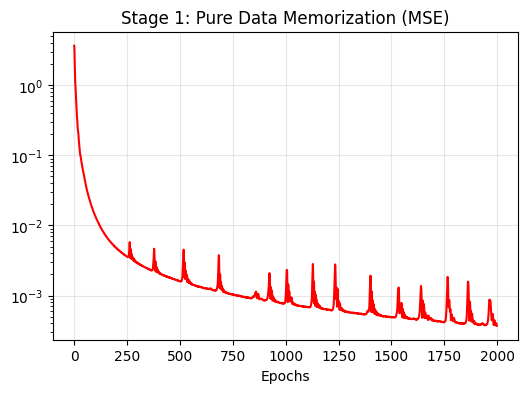

In [ ]:
# ==============================================================================
# STAGE 1: PURE DATA-LOSS MEMORIZATION CHECK (128 SAMPLES)
# ==============================================================================
print(f"--- STAGE 1: Memorizing {n_train} Samples with Pure Data Loss ---")

# Restructure training targets to Shape: (N_points, n_train)
u_train_all = jnp.array(all_u_flat[:n_train, :, 0].T)

# Initialize per-sample linear heads: W_heads has shape (total_features, n_train)
key, subkey = jax.random.split(key)
W_heads = jax.random.normal(subkey, (total_features, n_train)) * 0.01 # Creates the equivalent of the weights in nn.Dense(128, use_bias=False)

params_stage1 = {
    'backbone': initial_params,
    'heads': W_heads
}

optimizer_stage1 = optax.adamw(learning_rate=1e-3, weight_decay=1e-5)
opt_state_stage1 = optimizer_stage1.init(params_stage1)

@jax.jit
def compute_pure_data_loss(params_dict, x_grid, y_grid, u_targets):
    # F shape: (N_points, total_features)
    F = f_spatial_vmap(params_dict['backbone'], x_grid, y_grid)
    # U_pred shape: (N_points, n_train)
    U_pred = F @ params_dict['heads']
    loss_mse = jnp.mean((U_pred - u_targets) ** 2)
    return loss_mse

loss_grad_fn_stage1 = jax.jit(value_and_grad(compute_pure_data_loss, argnums=0))

@jax.jit
def update_stage1(params_dict, opt_state, x_grid, y_grid, u_targets):
    loss, grads = loss_grad_fn_stage1(params_dict, x_grid, y_grid, u_targets)
    updates, opt_state = optimizer_stage1.update(grads, opt_state, params=params_dict)
    new_params = optax.apply_updates(params_dict, updates)
    return new_params, opt_state, loss

epochs_stage1 = 2000
spatial_batch_size = 5000
history_data_stage1 = []

for epoch in tqdm(range(epochs_stage1), desc="Data-Loss Training"):
    # Shuffle spatial coordinates to avoid memory exhaustion
    rng, shuffle_key = jax.random.split(jax.random.PRNGKey(epoch))
    spatial_idx = jax.random.choice(shuffle_key, total_valid_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk, y_chunk = x[spatial_idx], y[spatial_idx]
    u_chunk = u_train_all[spatial_idx, :]
    
    params_stage1, opt_state_stage1, loss_val = update_stage1(
        params_stage1, opt_state_stage1, x_chunk, y_chunk, u_chunk
    )
    history_data_stage1.append(float(loss_val))
    
    if (epoch + 1) % 200 == 0:
        # Full grid eval
        full_loss = compute_pure_data_loss(params_stage1, x, y, u_train_all)
        print(f"Epoch {epoch+1:04d} | Pure Data MSE (128 samples): {full_loss:.4e}")

# Plot Stage 1 Loss
plt.figure(figsize=(6, 4))
plt.plot(history_data_stage1, color='red')
plt.yscale('log')
plt.title("Stage 1: Pure Data Memorization (MSE)")
plt.xlabel("Epochs")
plt.grid(True, alpha=0.3)
plt.show()

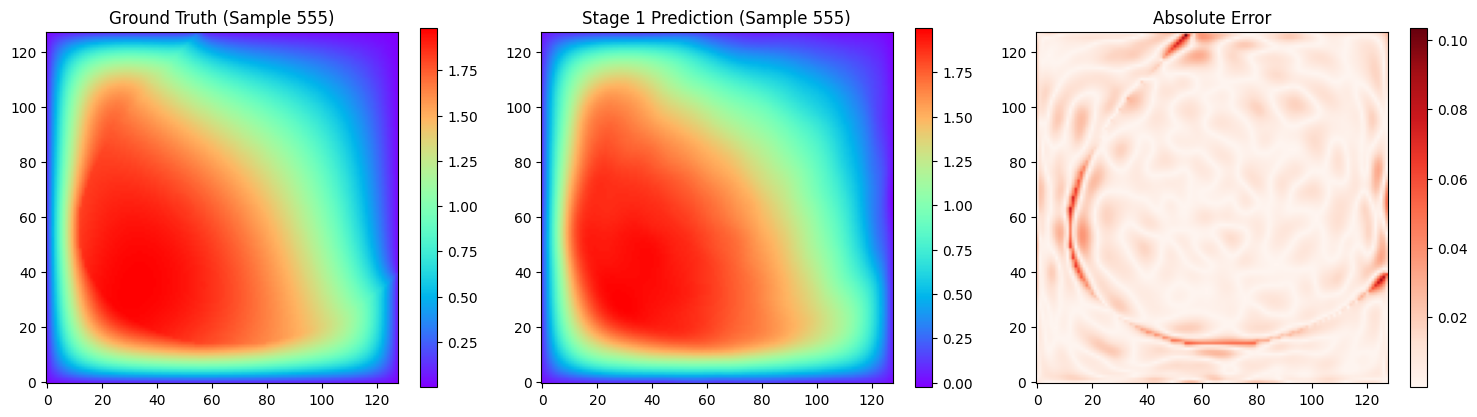

In [ ]:
# Pick any sample index from 0 to 127
sample_idx = 0 

# 1. Get the feature evaluations for the full spatial grid
f_eval_stage1 = f_spatial_vmap(params_stage1['backbone'], x, y)

# 2. Multiply by the specific head column for this sample
u_pred_sample = (f_eval_stage1 @ params_stage1['heads'][:, sample_idx]).reshape(fine_nx, fine_ny).T

# 3. Get the corresponding ground truth
u_true_sample = u_train_all[:, sample_idx].reshape(fine_nx, fine_ny).T

# 4. Plot Ground Truth vs Prediction vs Error
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(u_true_sample, origin='lower', cmap='rainbow')
axes[0].set_title(f"Ground Truth (Sample {sample_idx})")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u_pred_sample, origin='lower', cmap='rainbow')
axes[1].set_title(f"Stage 1 Prediction (Sample {sample_idx})")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(jnp.abs(u_true_sample - u_pred_sample), origin='lower', cmap='Reds')
axes[2].set_title("Absolute Error")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# STAGE 2: FROZEN BACKBONE + 1-SHOT PDE LINEAR SOLVE
# ==============================================================================
print("\n--- STAGE 2: Evaluating 1-Shot Physics Solve on Frozen Data Backbone ---")
frozen_params = params_stage1['backbone']

train_a_batch = jnp.array(all_a_flat[:n_train])
train_ax_batch = jnp.array(all_a_x_flat[:n_train])
train_ay_batch = jnp.array(all_a_y_flat[:n_train])
train_u_batch = jnp.array(all_u_flat[:n_train])

test_a_batch = jnp.array(all_a_flat[n_train:n_train+n_test])
test_ax_batch = jnp.array(all_a_x_flat[n_train:n_train+n_test])
test_ay_batch = jnp.array(all_a_y_flat[n_train:n_train+n_test])
test_u_batch = jnp.array(all_u_flat[n_train:n_train+n_test])

# Solve exactly via normal equations (pseudoinverse) using the Stage 1 features
w_train_pde = update_direct_solve_batch(
    frozen_params, x, y, train_a_batch, train_ax_batch, train_ay_batch,
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)

w_test_pde = update_direct_solve_batch(
    frozen_params, x, y, test_a_batch, test_ax_batch, test_ay_batch,
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)

@jax.jit
def fast_eval_step(params_bb, w_batch, x_grid, y_grid, u_batch):
    f_eval = f_spatial_vmap(params_bb, x_grid, y_grid)
    u_pred_batch = jnp.matmul(f_eval, w_batch)
    return jnp.mean((u_pred_batch - u_batch)**2)

train_pde_mse = fast_eval_step(frozen_params, w_train_pde, x, y, train_u_batch)
test_pde_mse = fast_eval_step(frozen_params, w_test_pde, x, y, test_u_batch)

print(f"Train Set 1-Shot PDE Solve Data MSE (128 samples): {train_pde_mse:.4e}")
print(f"Test Set  1-Shot PDE Solve Data MSE  (10 samples) : {test_pde_mse:.4e}")

# Visualizing Sample 0 Prediction vs Ground Truth
sample_idx = 0
f_eval_frozen = f_spatial_vmap(frozen_params, x, y)
u_pred_sample0 = (f_eval_frozen @ w_train_pde[sample_idx]).reshape(fine_nx, fine_ny).T
u_true_sample0 = train_u_batch[sample_idx].reshape(fine_nx, fine_ny).T

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(u_true_sample0, origin='lower', cmap='rainbow')
axes[0].set_title("Ground Truth (Sample 0)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u_pred_sample0, origin='lower', cmap='rainbow')
axes[1].set_title("Frozen Backbone 1-Shot PDE Solve")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(jnp.abs(u_true_sample0 - u_pred_sample0), origin='lower', cmap='Reds')
axes[2].set_title("Absolute Error")
fig.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.show()


--- STAGE 2: Evaluating 1-Shot Physics Solve on Frozen Data Backbone ---


E0730 23:56:47.453344  462066 gpu_hlo_schedule.cc:946] The byte size of input/output arguments (140509184000) exceeds the base limit (6871528243). This indicates an error in the calculation!
E0730 23:56:47.453325  462063 gpu_hlo_schedule.cc:946] The byte size of input/output arguments (140509184000) exceeds the base limit (6871528243). This indicates an error in the calculation!
E0730 23:56:47.453382  462078 gpu_hlo_schedule.cc:946] The byte size of input/output arguments (140509184000) exceeds the base limit (6871528243). This indicates an error in the calculation!
W0730 23:56:47.453551  462066 hlo_rematerialization.cc:3233] Can't reduce memory use below 1.95GiB (2097152000 bytes) by rematerialization; only reduced to 1.96GiB (2101346320 bytes), down from 1.96GiB (2101346320 bytes) originally
W0730 23:56:47.453568  462063 hlo_rematerialization.cc:3233] Can't reduce memory use below 1.95GiB (2097152000 bytes) by rematerialization; only reduced to 1.96GiB (2101346320 bytes), down from 1

JaxRuntimeError: RESOURCE_EXHAUSTED: Autotuning failed for HLO: %custom-call.41 = (f64[1000,512,512]{2,1,0}, s8[4194304]{0}) custom-call(%concatenate.78, %concatenate.78), custom_call_target="__cublas$lt$matmul", metadata={op_name="jit(update_direct_solve_batch)/vmap()/dot_general" stack_frame_id=163}, backend_config={"operation_queue_id":"0","gemm_backend_config":{"alpha_real":1,"beta":0,"dot_dimension_numbers":{"lhs_contracting_dimensions":["1"],"rhs_contracting_dimensions":["1"],"lhs_batch_dimensions":["0"],"rhs_batch_dimensions":["0"]},"alpha_imag":0,"precision_config":{"operand_precision":["DEFAULT","DEFAULT"],"algorithm":"ALG_UNSET"},"epilogue":"DEFAULT","lhs_stride":"8650752","rhs_stride":"8650752","grad_x":false,"grad_y":false,"damax_output":false,"autotune_workspace_size":"0","scale_mode":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}. Failed to profile configs: Out of memory while trying to allocate 64.47GiB.

In [ ]:
# # ==============================================================================
# # STAGE 3: FINE-TUNE BACKBONE WITH PURE PDE + BC LOSS
# # ==============================================================================
# print("\n--- STAGE 3: Fine-Tuning Backbone with Pure Physics (PDE + BC) Loss ---")

# # Differentiable Loss and Gradients
# def compute_loss_single(params, w_current, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch):
#     u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
#     laplacian_u = u_xx + u_yy
#     pde_residual = -(a_x_batch * u_x + a_y_batch * u_y + a_batch * laplacian_u) - beta
#     f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
#     u_bc_pred = jnp.dot(f_bc_vals, w_current)
#     f_interior = f_spatial_vmap(params, x_batch, y_batch)
#     u_pred_interior = jnp.dot(f_interior, w_current)
    
#     loss_pde_unscaled = jnp.mean(pde_residual ** 2)
#     loss_bc_unscaled = jnp.mean((u_bc_pred - bc_val_arr) ** 2)
#     loss_data_unscaled = jnp.mean((u_pred_interior - u_batch) ** 2)
    
#     loss_pde_scaled = loss_pde_unscaled * pde_loss_weight
#     loss_bc_scaled = loss_bc_unscaled * bc_loss_weight
#     loss_data_scaled = loss_data_unscaled * data_loss_weight # == 0.0
    
#     return (loss_pde_scaled, loss_bc_scaled, loss_data_scaled), (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)

# batched_compute_loss = jax.vmap(compute_loss_single, in_axes=(None, 0, None, None, 0, 0, 0, None, None, None, 0))

# def compute_pde_bc_losses(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
#     w_batch = update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
#     scaled_tup, unscaled_tup = batched_compute_loss(params, w_batch, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch)
#     l_pde_scaled, l_bc_scaled, l_data_scaled = jnp.mean(scaled_tup[0]), jnp.mean(scaled_tup[1]), jnp.mean(scaled_tup[2])
    
#     loss_components = jnp.stack([l_pde_scaled, l_bc_scaled])
#     primals_scaled = (l_pde_scaled, l_bc_scaled, l_data_scaled)
#     aux_unscaled = (jnp.mean(unscaled_tup[0]), jnp.mean(unscaled_tup[1]), jnp.mean(unscaled_tup[2]))
#     return loss_components, (primals_scaled, aux_unscaled)

# loss_jac_fn = jax.jit(jax.jacrev(compute_pde_bc_losses, argnums=0, has_aux=True), static_argnames=['total_features', 'chunk_size'])

# total_steps_s3 = 100 * len(train_dataloader)
# lr_schedule_s3 = optax.cosine_decay_schedule(init_value=1e-4, decay_steps=total_steps_s3, alpha=0.01)
# optimizer_s3 = optax.adamw(learning_rate=lr_schedule_s3, weight_decay=1e-4)

# # Start Stage 3 from the Frozen Backbone
# params_stage3 = frozen_params
# opt_state_stage3 = optimizer_s3.init(params_stage3)

# @jax.jit(static_argnames=['total_features', 'chunk_size'])
# def update_network_stage3(params, opt_state, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
#     jac_grads, (primals_scaled, aux_unscaled) = loss_jac_fn(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size)
#     total_grads = tree_map(lambda x: jnp.sum(x, axis=0), jac_grads)
#     updates, opt_state = optimizer_s3.update(total_grads, opt_state, params=params)
#     new_params = optax.apply_updates(params, updates)
#     return new_params, opt_state, primals_scaled, aux_unscaled

# epochs_stage3 = 100
# history_pde_s3, history_bc_s3, history_data_s3 = [], [], []

# for epoch in tqdm(range(epochs_stage3), desc="Physics Fine-Tuning"):
#     ep_pde, ep_bc, ep_data, num_batches = 0.0, 0.0, 0.0, 0
    
#     for a_batch, a_x_batch, a_y_batch, u_batch in train_dataloader:
#         rng, pde_key, bc_key = jax.random.split(jax.random.PRNGKey(epoch + num_batches), 3)
#         spatial_idx = jax.random.choice(pde_key, total_valid_points, shape=(5000,), replace=False)
#         bc_idx = jax.random.choice(bc_key, x_bc.shape[0], shape=(512,), replace=False)
        
#         params_stage3, opt_state_stage3, primals, unscaled = update_network_stage3(
#             params_stage3, opt_state_stage3, 
#             x[spatial_idx], y[spatial_idx],
#             a_batch[:, spatial_idx, :], a_x_batch[:, spatial_idx, :], a_y_batch[:, spatial_idx, :],
#             x_bc[bc_idx], y_bc[bc_idx], bc_val_array[bc_idx], 
#             u_batch[:, spatial_idx, :], total_features, chunk_size
#         )
#         ep_pde += unscaled[0]
#         ep_bc += unscaled[1]
#         ep_data += unscaled[2]
#         num_batches += 1
        
#     history_pde_s3.append(float(ep_pde / num_batches))
#     history_bc_s3.append(float(ep_bc / num_batches))
#     history_data_s3.append(float(ep_data / num_batches))
    
#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1:03d} | Train PDE: {history_pde_s3[-1]:.3e} | Train BC: {history_bc_s3[-1]:.3e} | Train Data MSE: {history_data_s3[-1]:.3e}")

# # Plotting Stage 3 Progress
# fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# axes[0].plot(history_pde_s3, color='blue')
# axes[0].set_title("Stage 3 PDE Loss (Unscaled)")
# axes[0].set_yscale('log')

# axes[1].plot(history_bc_s3, color='green')
# axes[1].set_title("Stage 3 BC Loss (Unscaled)")
# axes[1].set_yscale('log')

# axes[2].plot(history_data_s3, color='red')
# axes[2].set_title("Stage 3 Train Data MSE")
# axes[2].set_yscale('log')

# for ax in axes: ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()